In [1]:
pip install gseapy

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import gseapy as gp

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\PC\MI-Matcha-SystemsBio


In [3]:
gene_file = DATA_DIR / "EGCG_gene_list.csv"

genes_df = pd.read_csv(gene_file)

genes_df.head()

,Gene
0,ABCB1
1,ABCC1
2,ABCG2
3,ACHE
4,ADAMTS4


In [4]:
genes = (
    genes_df["Gene"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
    .drop_duplicates()
    .tolist()
)

print("Number of genes:", len(genes))
print(genes[:20])

Number of genes: 96
['ABCB1', 'ABCC1', 'ABCG2', 'ACHE', 'ADAMTS4', 'ADAMTS5', 'ADORA3', 'ALOX5', 'APP', 'AXL', 'BACE1', 'BCL2', 'CA1', 'CA12', 'CA2', 'CA3', 'CA4', 'CA5A', 'CA5B', 'CA6']


In [5]:
libraries = gp.get_library_name(organism="Human")

print("Number of available libraries:", len(libraries))
print(libraries[:20])

Number of available libraries: 228
['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020']


In [6]:
for keyword in ["GO_Biological", "GO_Molecular", "GO_Cellular", "KEGG", "Reactome"]:
    print(f"\n--- {keyword} ---")
    print([lib for lib in libraries if keyword.lower() in lib.lower()][:20])


--- GO_Biological ---
['GO_Biological_Process_2021', 'GO_Biological_Process_2023', 'GO_Biological_Process_2025', 'GO_Biological_Process_2026']

--- GO_Molecular ---
['GO_Molecular_Function_2021', 'GO_Molecular_Function_2023', 'GO_Molecular_Function_2025', 'GO_Molecular_Function_2026']

--- GO_Cellular ---
['GO_Cellular_Component_2021', 'GO_Cellular_Component_2023', 'GO_Cellular_Component_2025', 'GO_Cellular_Component_2026']

--- KEGG ---
['KEGG_2013', 'KEGG_2015', 'KEGG_2016', 'KEGG_2019_Human', 'KEGG_2019_Mouse', 'KEGG_2021_Human', 'KEGG_2026']

--- Reactome ---
['Reactome_2022', 'Reactome_Pathways_2024']


In [7]:
selected_libraries = [
    "GO_Biological_Process_2025",
    "GO_Molecular_Function_2025",
    "GO_Cellular_Component_2025",
    "KEGG_2021_Human",
    "Reactome_2022"
]

selected_libraries

['GO_Biological_Process_2025',
 'GO_Molecular_Function_2025',
 'GO_Cellular_Component_2025',
 'KEGG_2021_Human',
 'Reactome_2022']

In [8]:
enrichment = gp.enrichr(
    gene_list=genes,
    gene_sets=selected_libraries,
    organism="human",
    outdir=None,
    cutoff=0.05
)

results = enrichment.results

print("Number of enrichment results:", len(results))
results.head()

Number of enrichment results: 2929


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Protein Phosphorylation (GO:0006468),18/373,1.800667e-13,2.938689e-10,0,0,12.707909,372.919294,GSK3B;DYRK3;DYRK2;PRKAA2;FLT3;SRC;PLK1;DYRK1A;...
1,GO_Biological_Process_2025,Cellular Component Disassembly (GO:0022411),9/49,1.615932e-12,1.318601e-09,0,0,51.372414,1394.818019,ADAMTS4;MMP12;ADAMTS5;DYRK3;MMP14;MMP13;MMP1;M...
2,GO_Biological_Process_2025,Extracellular Matrix Disassembly (GO:0022617),8/45,3.898338e-11,2.120696e-08,0,0,48.813268,1169.950824,ADAMTS4;MMP12;ADAMTS5;MMP14;MMP13;MMP1;MMP2;MMP9
3,GO_Biological_Process_2025,Cell Surface Receptor Protein Tyrosine Kinase ...,14/296,1.435724e-10,5.857755e-08,0,0,11.879779,269.245458,GSK3B;FLT3;SRC;MMP2;MAPK14;MMP9;PGF;VEGFA;PIK3...
4,GO_Biological_Process_2025,Phosphorylation (GO:0016310),13/298,1.835497e-09,4.998998e-07,0,0,10.781949,216.889150,GSK3B;DYRK3;DYRK2;PRKAA2;PLK1;DYRK1A;DYRK1B;CS...


In [9]:
print(results.columns.tolist())
results.info()

['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Old P-value', 'Old Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes']
<class 'pandas.DataFrame'>
RangeIndex: 2929 entries, 0 to 2928
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gene_set              2929 non-null   str    
 1   Term                  2929 non-null   str    
 2   Overlap               2929 non-null   str    
 3   P-value               2929 non-null   float64
 4   Adjusted P-value      2929 non-null   float64
 5   Old P-value           2929 non-null   int64  
 6   Old Adjusted P-value  2929 non-null   int64  
 7   Odds Ratio            2929 non-null   float64
 8   Combined Score        2929 non-null   float64
 9   Genes                 2929 non-null   str    
dtypes: float64(4), int64(2), str(4)
memory usage: 229.0 KB


In [10]:
significant_results = (
    results[
        results["Adjusted P-value"] < 0.05
    ]
    .sort_values(
        ["Gene_set", "Adjusted P-value"]
    )
    .reset_index(drop=True)
)

print("Significant terms:", len(significant_results))

significant_results.head(20)

Significant terms: 810


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Protein Phosphorylation (GO:0006468),18/373,1.800667e-13,2.938689e-10,0,0,12.707909,372.919294,GSK3B;DYRK3;DYRK2;PRKAA2;FLT3;SRC;PLK1;DYRK1A;...
1,GO_Biological_Process_2025,Cellular Component Disassembly (GO:0022411),9/49,1.615932e-12,1.318601e-09,0,0,51.372414,1394.818019,ADAMTS4;MMP12;ADAMTS5;DYRK3;MMP14;MMP13;MMP1;M...
2,GO_Biological_Process_2025,Extracellular Matrix Disassembly (GO:0022617),8/45,3.898338e-11,2.120696e-08,0,0,48.813268,1169.950824,ADAMTS4;MMP12;ADAMTS5;MMP14;MMP13;MMP1;MMP2;MMP9
3,GO_Biological_Process_2025,Cell Surface Receptor Protein Tyrosine Kinase ...,14/296,1.435724e-10,5.857755e-08,0,0,11.879779,269.245458,GSK3B;FLT3;SRC;MMP2;MAPK14;MMP9;PGF;VEGFA;PIK3...
4,GO_Biological_Process_2025,Phosphorylation (GO:0016310),13/298,1.835497e-09,4.998998e-07,0,0,10.781949,216.889150,GSK3B;DYRK3;DYRK2;PRKAA2;PLK1;DYRK1A;DYRK1B;CS...
5,GO_Biological_Process_2025,Response to Amyloid-Beta (GO:1904645),7/45,1.837867e-09,4.998998e-07,0,0,41.118273,827.080093,MMP12;APP;GSK3B;MMP13;MMP2;FYN;MMP9
6,GO_Biological_Process_2025,External Encapsulating Structure Organization ...,9/111,3.116347e-09,6.357349e-07,0,0,20.083164,393.360991,ADAMTS4;MMP12;APP;ADAMTS5;MMP14;MMP13;MMP1;MMP...
7,GO_Biological_Process_2025,Extracellular Structure Organization (GO:0043062),9/111,3.116347e-09,6.357349e-07,0,0,20.083164,393.360991,ADAMTS4;MMP12;APP;ADAMTS5;MMP14;MMP13;MMP1;MMP...
8,GO_Biological_Process_2025,Cellular Response to Oxygen-Containing Compoun...,14/384,4.198679e-09,7.401799e-07,0,0,9.013711,173.860933,APP;GSK3B;ABCC1;SRC;SERPINE1;MAPK14;MMP9;ESR1;...
9,GO_Biological_Process_2025,Vascular Endothelial Growth Factor Receptor Si...,6/29,4.535416e-09,7.401799e-07,0,0,57.626087,1107.074868,SRC;KDR;FYN;MAPK14;PGF;VEGFA


In [11]:
results.to_csv(
    TABLE_DIR / "EGCG_enrichment_all_results.csv",
    index=False
)

significant_results.to_csv(
    TABLE_DIR / "EGCG_enrichment_significant_results.csv",
    index=False
)

print("Enrichment tables saved.")

Enrichment tables saved.


In [12]:
significant_counts = (
    significant_results["Gene_set"]
    .value_counts()
    .rename_axis("Gene_set")
    .reset_index(name="Significant_terms")
)

significant_counts

,Gene_set,Significant_terms
0,GO_Biological_Process_2025,432
1,Reactome_2022,194
2,KEGG_2021_Human,111
3,GO_Molecular_Function_2025,54
4,GO_Cellular_Component_2025,19


In [13]:
def get_top_terms(
    enrichment_df: pd.DataFrame,
    gene_set: str,
    number: int = 10
) -> pd.DataFrame:
    """Return the most significant terms for one enrichment library."""

    subset = enrichment_df[
        enrichment_df["Gene_set"] == gene_set
    ].copy()

    subset = subset.sort_values(
        "Adjusted P-value",
        ascending=True
    ).head(number)

    return subset

In [14]:
go_bp_library = [
    lib for lib in selected_libraries
    if "GO_Biological_Process" in lib
][0]

top_go_bp = get_top_terms(
    significant_results,
    go_bp_library,
    number=10
)

top_go_bp[
    [
        "Term",
        "Overlap",
        "Adjusted P-value",
        "Combined Score",
        "Genes"
    ]
]

,Term,Overlap,Adjusted P-value,Combined Score,Genes
0,Protein Phosphorylation (GO:0006468),18/373,2.938689e-10,372.919294,GSK3B;DYRK3;DYRK2;PRKAA2;FLT3;SRC;PLK1;DYRK1A;...
1,Cellular Component Disassembly (GO:0022411),9/49,1.318601e-09,1394.818019,ADAMTS4;MMP12;ADAMTS5;DYRK3;MMP14;MMP13;MMP1;M...
2,Extracellular Matrix Disassembly (GO:0022617),8/45,2.120696e-08,1169.950824,ADAMTS4;MMP12;ADAMTS5;MMP14;MMP13;MMP1;MMP2;MMP9
3,Cell Surface Receptor Protein Tyrosine Kinase ...,14/296,5.857755e-08,269.245458,GSK3B;FLT3;SRC;MMP2;MAPK14;MMP9;PGF;VEGFA;PIK3...
4,Phosphorylation (GO:0016310),13/298,4.998998e-07,216.889150,GSK3B;DYRK3;DYRK2;PRKAA2;PLK1;DYRK1A;DYRK1B;CS...
5,Response to Amyloid-Beta (GO:1904645),7/45,4.998998e-07,827.080093,MMP12;APP;GSK3B;MMP13;MMP2;FYN;MMP9
6,External Encapsulating Structure Organization ...,9/111,6.357349e-07,393.360991,ADAMTS4;MMP12;APP;ADAMTS5;MMP14;MMP13;MMP1;MMP...
7,Extracellular Structure Organization (GO:0043062),9/111,6.357349e-07,393.360991,ADAMTS4;MMP12;APP;ADAMTS5;MMP14;MMP13;MMP1;MMP...
8,Cellular Response to Oxygen-Containing Compoun...,14/384,7.401799e-07,173.860933,APP;GSK3B;ABCC1;SRC;SERPINE1;MAPK14;MMP9;ESR1;...
9,Vascular Endothelial Growth Factor Receptor Si...,6/29,7.401799e-07,1107.074868,SRC;KDR;FYN;MAPK14;PGF;VEGFA


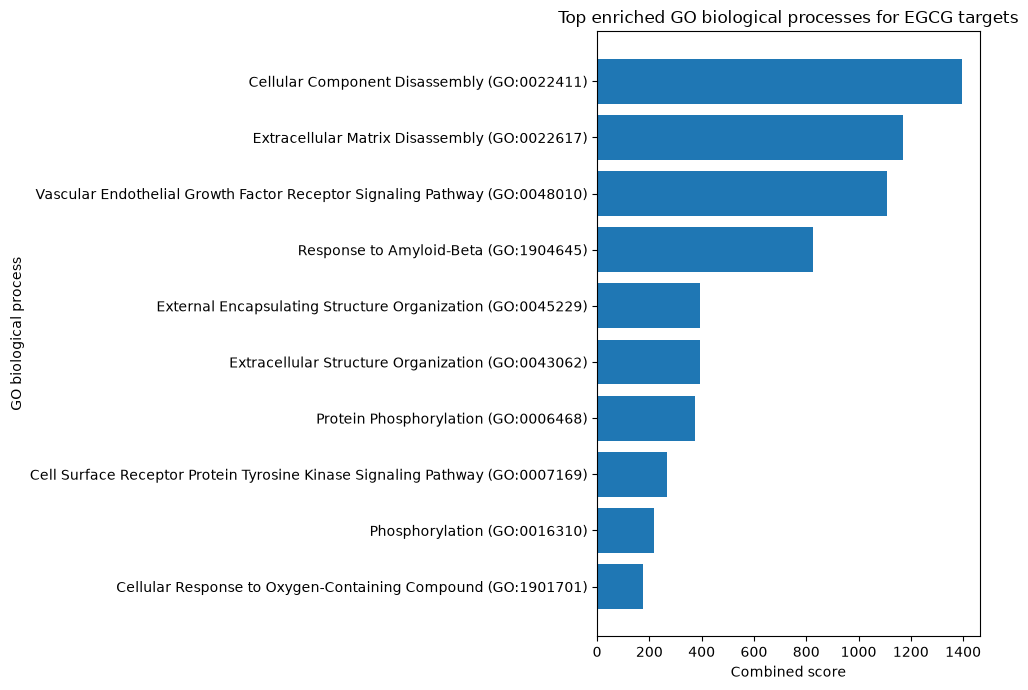

In [15]:
plot_data = top_go_bp.sort_values(
    "Combined Score",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["Term"],
    plot_data["Combined Score"]
)

plt.title("Top enriched GO biological processes for EGCG targets")
plt.xlabel("Combined score")
plt.ylabel("GO biological process")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "EGCG_GO_biological_processes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
kegg_library = [
    lib for lib in selected_libraries
    if "KEGG" in lib
][0]

top_kegg = get_top_terms(
    significant_results,
    kegg_library,
    number=10
)

top_kegg[
    [
        "Term",
        "Overlap",
        "Adjusted P-value",
        "Combined Score",
        "Genes"
    ]
]

,Term,Overlap,Adjusted P-value,Combined Score,Genes
505,Nitrogen metabolism,10/17,1.537454e-17,14551.589789,CA12;CA1;CA3;CA5B;CA2;CA5A;CA4;CA7;CA6;CA9
506,Central carbon metabolism in cancer,10/70,1.274595e-10,1053.857980,PKM;PIK3CA;FLT3;PGAM1;KIT;SIRT6;MET;HIF1A;MTOR...
507,Pathways in cancer,19/531,4.736943e-10,240.046830,GSK3B;FLT3;MMP1;STAT1;MMP2;MMP9;HIF1A;ESR1;PGF...
508,Proteoglycans in cancer,12/205,1.452454e-08,320.604125,PIK3CA;SRC;MMP2;KDR;MAPK14;MMP9;MET;HIF1A;ESR1...
509,PI3K-Akt signaling pathway,13/354,5.865211e-07,162.215188,GSK3B;PRKAA2;FLT3;PGF;MTOR;VEGFA;PIK3CA;KIT;CD...
510,Fluid shear stress and atherosclerosis,9/139,7.660104e-07,276.996236,PRKAA2;PIK3CA;SRC;MMP2;KDR;BCL2;MAPK14;MMP9;VEGFA
511,Prolactin signaling pathway,7/70,1.277262e-06,419.561297,GSK3B;PIK3CA;SRC;STAT1;MAPK14;ESR1;ESR2
512,MAPK signaling pathway,11/294,4.246590e-06,139.997727,RPS6KA3;FLT3;KIT;KDR;MAPKAPK5;MAPT;MAPK14;MET;...
513,Relaxin signaling pathway,8/129,4.474510e-06,229.386116,MMP13;PIK3CA;MMP1;SRC;MMP2;MAPK14;MMP9;VEGFA
514,Chemical carcinogenesis,10/239,4.584541e-06,152.886774,RPS6KA3;CBR1;PIK3CA;SRC;BCL2;CYP1B1;ESR1;ESR2;...


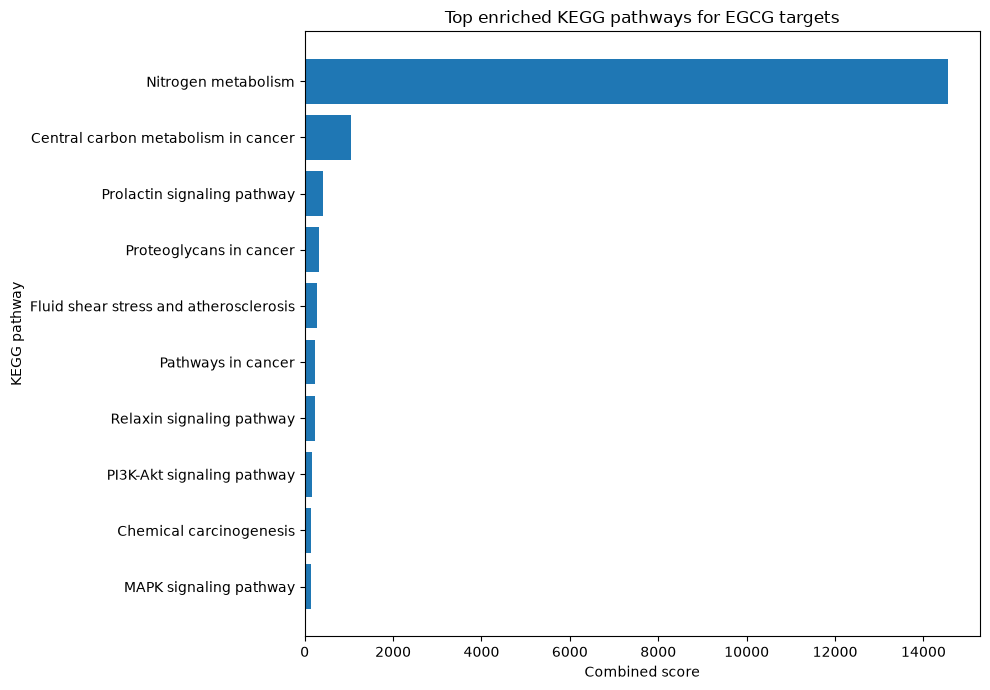

In [17]:
plot_data = top_kegg.sort_values(
    "Combined Score",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["Term"],
    plot_data["Combined Score"]
)

plt.title("Top enriched KEGG pathways for EGCG targets")
plt.xlabel("Combined score")
plt.ylabel("KEGG pathway")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "EGCG_KEGG_pathways.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
reactome_library = [
    lib for lib in selected_libraries
    if "Reactome" in lib
][0]

top_reactome = get_top_terms(
    significant_results,
    reactome_library,
    number=10
)

top_reactome[
    [
        "Term",
        "Overlap",
        "Adjusted P-value",
        "Combined Score",
        "Genes"
    ]
]

,Term,Overlap,Adjusted P-value,Combined Score,Genes
616,Reversible Hydration Of Carbon Dioxide R-HSA-1...,10/12,1.886721e-19,57500.033763,CA12;CA1;CA3;CA5B;CA2;CA5A;CA4;CA7;CA6;CA9
617,Signal Transduction R-HSA-162582,38/2465,4.290485e-09,118.670286,APP;GSK3B;PRKAA2;KDM1A;FLT3;SRC;SERPINE1;KLK2;...
618,PI3K/AKT Signaling In Cancer R-HSA-2219528,10/105,1.910707e-08,563.813275,GSK3B;PIK3CA;FLT3;SRC;KIT;FYN;ESR1;ESR2;MTOR;F...
619,Metabolism R-HSA-1430728,33/2049,2.786093e-08,104.988469,ACHE;PRKAA2;CYP19A1;FUT4;PTGS1;CA1;FUT7;PSMB5;...
620,Signaling By Receptor Tyrosine Kinases R-HSA-9...,17/496,2.853548e-08,194.970115,FLT3;SRC;STAT1;MAPK14;MMP9;HIF1A;ESR1;PGF;MTOR...
621,Signaling By VEGF R-HSA-194138,9/102,1.756016e-07,448.282598,PIK3CA;SRC;AXL;KDR;FYN;MAPK14;PGF;MTOR;VEGFA
622,Degradation Of Extracellular Matrix R-HSA-1474228,9/109,2.725807e-07,404.589005,ADAMTS4;MMP12;ADAMTS5;MMP14;MMP13;MMP1;MMP2;KL...
623,Constitutive Signaling By Aberrant PI3K In Can...,8/78,3.289288e-07,499.915797,PIK3CA;FLT3;SRC;KIT;FYN;ESR1;ESR2;FGFR1
624,Signaling By Interleukins R-HSA-449147,15/453,3.289288e-07,158.920082,APP;MMP1;STAT1;MMP2;MAPK14;MMP9;HIF1A;VEGFA;RP...
625,Disease R-HSA-1643685,28/1736,3.947618e-07,83.119203,APP;GSK3B;DNMT1;KDM1A;FLT3;SRC;CYP19A1;HDAC6;A...


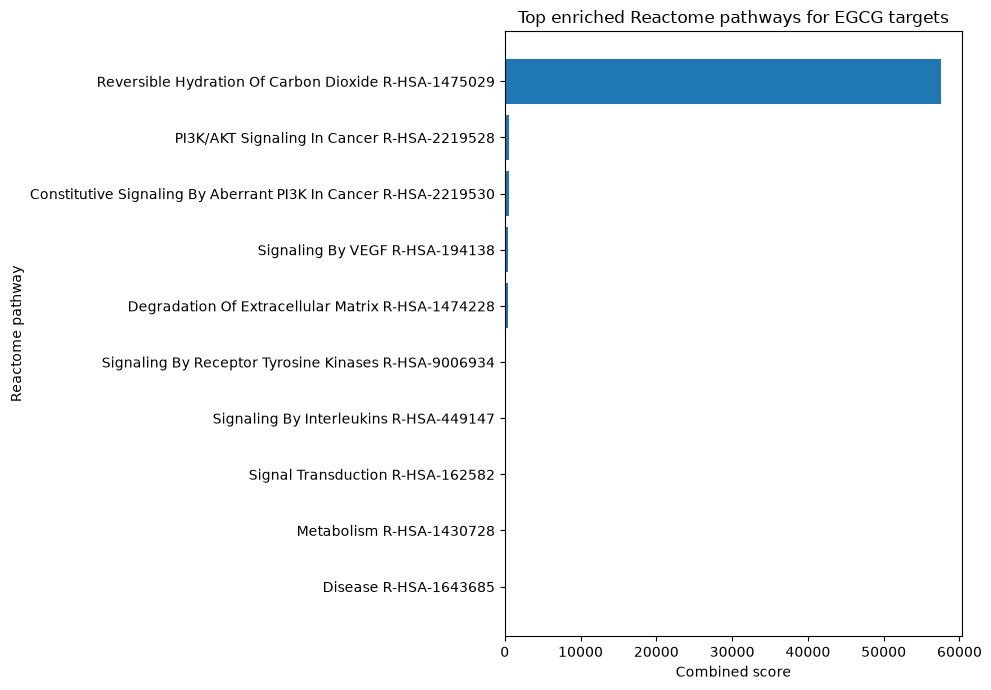

In [19]:
plot_data = top_reactome.sort_values(
    "Combined Score",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["Term"],
    plot_data["Combined Score"]
)

plt.title("Top enriched Reactome pathways for EGCG targets")
plt.xlabel("Combined score")
plt.ylabel("Reactome pathway")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "EGCG_Reactome_pathways.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
%who

DATA_DIR	 FIGURE_DIR	 PROJECT_ROOT	 Path	 TABLE_DIR	 enrichment	 gene_file	 genes	 genes_df	 
get_top_terms	 go_bp_library	 gp	 kegg_library	 keyword	 libraries	 pd	 plot_data	 plt	 
reactome_library	 results	 selected_libraries	 significant_counts	 significant_results	 top_go_bp	 top_kegg	 top_reactome	 
